In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

R, F = Path("predict_results"), Path("predict_results/figures")
per_seed = pd.read_csv(R / "test_metrics_per_seed.csv")
refs = pd.read_csv(R / "test_metrics_summary.csv", index_col=0)[["real test", "real val (ref)"]]
mean = per_seed.drop(columns="seed").groupby("model", sort=False).mean().T
std = per_seed.drop(columns="seed").groupby("model", sort=False).std().T
real = pd.to_numeric(refs["real test"], errors="coerce")

def distance(metric, v):
    """How far a model is from ideal: KLs lower is better, SSIM higher, everything else closest to real test."""
    if metric.startswith("KL"):
        return v
    if "SSIM" in metric:
        return -v
    return abs(v - real[metric])

dist = pd.DataFrame({c: [distance(m, mean.loc[m, c]) for m in mean.index] for c in mean.columns}, index=mean.index)
best = dist.eq(dist.min(axis=1), axis=0)

table = pd.concat([mean.round(3).astype(str) + " ± " + std.round(3).astype(str), refs], axis=1)
def highlight(_):
    css = pd.DataFrame("", index=table.index, columns=table.columns)
    css[best.columns] = best.replace({True: "background-color: rgba(46,160,67,0.35); font-weight: bold", False: ""})
    return css

display(table.style.apply(highlight, axis=None)
        .format("{:.3f}", subset=["real test", "real val (ref)"], na_rep="-")
        .set_caption("TEST SET (14:45–15:45), mean ± std over 3 seeds. Green = closest to real. "
                     "'real val (ref)' = a different real hour scored like a generator: the best an ideal model could expect."))

,TimeGAN + head (ae10k),TimeGAN + head (trial 2),"TimeGAN, no head",RNN-GAN + head (baseline),"RNN-GAN, no head",real test,real val (ref)
Spread mean (ticks),12.824 ± 0.355,12.826 ± 0.201,12.839 ± 0.076,10.307 ± 0.237,11.594 ± 2.701,11.353,11.381
Spread std (ticks),3.846 ± 0.097,3.817 ± 0.268,4.15 ± 0.249,3.889 ± 0.846,3.695 ± 0.799,3.857,3.598
5s return std (bps),1.766 ± 0.06,1.629 ± 0.03,1.738 ± 0.228,1.315 ± 0.173,1.405 ± 0.578,2.005,1.507
Mean 5s return (bps),-0.057 ± 0.032,-0.013 ± 0.067,0.039 ± 0.209,-0.537 ± 0.849,-0.717 ± 0.694,-0.033,-0.008
Windows trending up (%),46.132 ± 2.006,47.612 ± 2.982,54.394 ± 16.489,36.533 ± 38.207,8.596 ± 13.787,45.702,46.915
Zero returns (%),6.075 ± 0.412,7.374 ± 2.602,6.443 ± 1.184,10.787 ± 7.936,7.73 ± 2.695,29.161,36.585
Diversity: std of window-mean spread,1.789 ± 0.319,2.023 ± 0.404,1.301 ± 0.439,0.587 ± 0.175,0.659 ± 0.239,2.033,1.606
Vol clustering: ACF |ret| lag 1,0.248 ± 0.081,0.455 ± 0.08,0.274 ± 0.058,0.472 ± 0.387,-0.097 ± 0.272,0.135,0.103
Crossed books (%),0.0 ± 0.0,0.0 ± 0.0,0.004 ± 0.007,0.0 ± 0.0,0.002 ± 0.003,0.000,0.000
Ladder out of order (%),0.0 ± 0.0,0.0 ± 0.0,44.403 ± 7.176,0.0 ± 0.0,32.124 ± 9.762,0.000,0.000


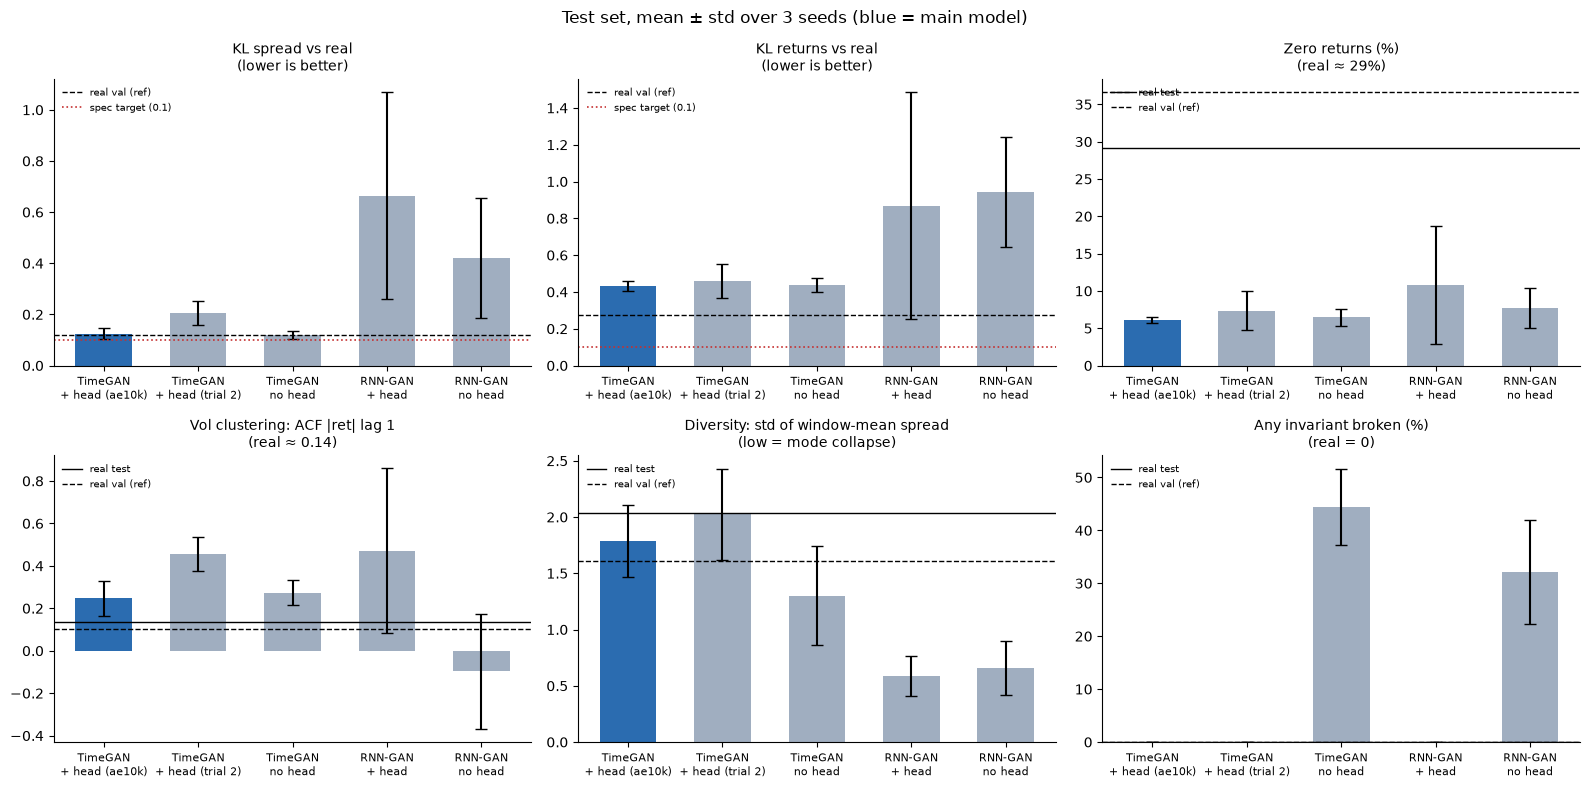

In [6]:
KEY = {"KL spread vs real": "lower is better", "KL returns vs real": "lower is better",
       "Zero returns (%)": "real ≈ 29%", "Vol clustering: ACF |ret| lag 1": "real ≈ 0.14",
       "Diversity: std of window-mean spread": "low = mode collapse", "Any invariant broken (%)": "real = 0"}
MAIN = "TimeGAN + head (ae10k)"
short = [m.replace(" (baseline)", "").replace(", no head", "\nno head").replace(" + head", "\n+ head") for m in mean.columns]
colours = ["#2b6cb0" if m == MAIN else "#a0aec0" for m in mean.columns]   # main model in blue, others grey

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (metric, note) in zip(axes.ravel(), KEY.items()):
    ax.bar(short, mean.loc[metric], yerr=std.loc[metric], color=colours, capsize=4, width=0.6)
    for col, style in [("real test", "-"), ("real val (ref)", "--")]:
        v = pd.to_numeric(refs.loc[metric, col], errors="coerce")
        if pd.notna(v):
            ax.axhline(v, color="black", ls=style, lw=1, label=col)
    if metric.startswith("KL"):
        ax.axhline(0.1, color="#c53030", ls=":", lw=1.2, label="spec target (0.1)")
    ax.legend(fontsize=7, loc="upper left", frameon=False)
    ax.set_title(f"{metric}\n({note})", fontsize=10); ax.tick_params(axis="x", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Test set, mean ± std over 3 seeds (blue = main model)", fontsize=12)
fig.tight_layout(); fig.savefig(F / "summary_metrics.png", dpi=150, bbox_inches="tight"); plt.show()

In [9]:
SPEC = {"KL spread vs real": ("≤ 0.1", lambda v: v <= 0.1),
        "KL returns vs real": ("≤ 0.1", lambda v: v <= 0.1),
        "Heatmap SSIM vs real (best match)": ("> 0.6", lambda v: v > 0.6),
        "Any invariant broken (%)": ("≤ 1%", lambda v: v <= 1)}
rows = list(SPEC)
spec = pd.DataFrame({
    "main model": mean.loc[rows, MAIN],
    "target": [SPEC[r][0] for r in rows],
    "met?": ["yes" if SPEC[r][1](mean.loc[r, MAIN]) else "no" for r in rows],
    "real vs real": pd.to_numeric(refs.loc[rows, "real val (ref)"], errors="coerce")})
display(spec.round(3).style.format(precision=3).set_caption(f"Spec targets: {MAIN} (test, mean of 3 seeds) vs a different real hour"))

,main model,target,met?,real vs real
KL spread vs real,0.125,≤ 0.1,no,0.118
KL returns vs real,0.433,≤ 0.1,no,0.277
Heatmap SSIM vs real (best match),0.306,> 0.6,no,0.258
Any invariant broken (%),0.000,≤ 1%,yes,0.000


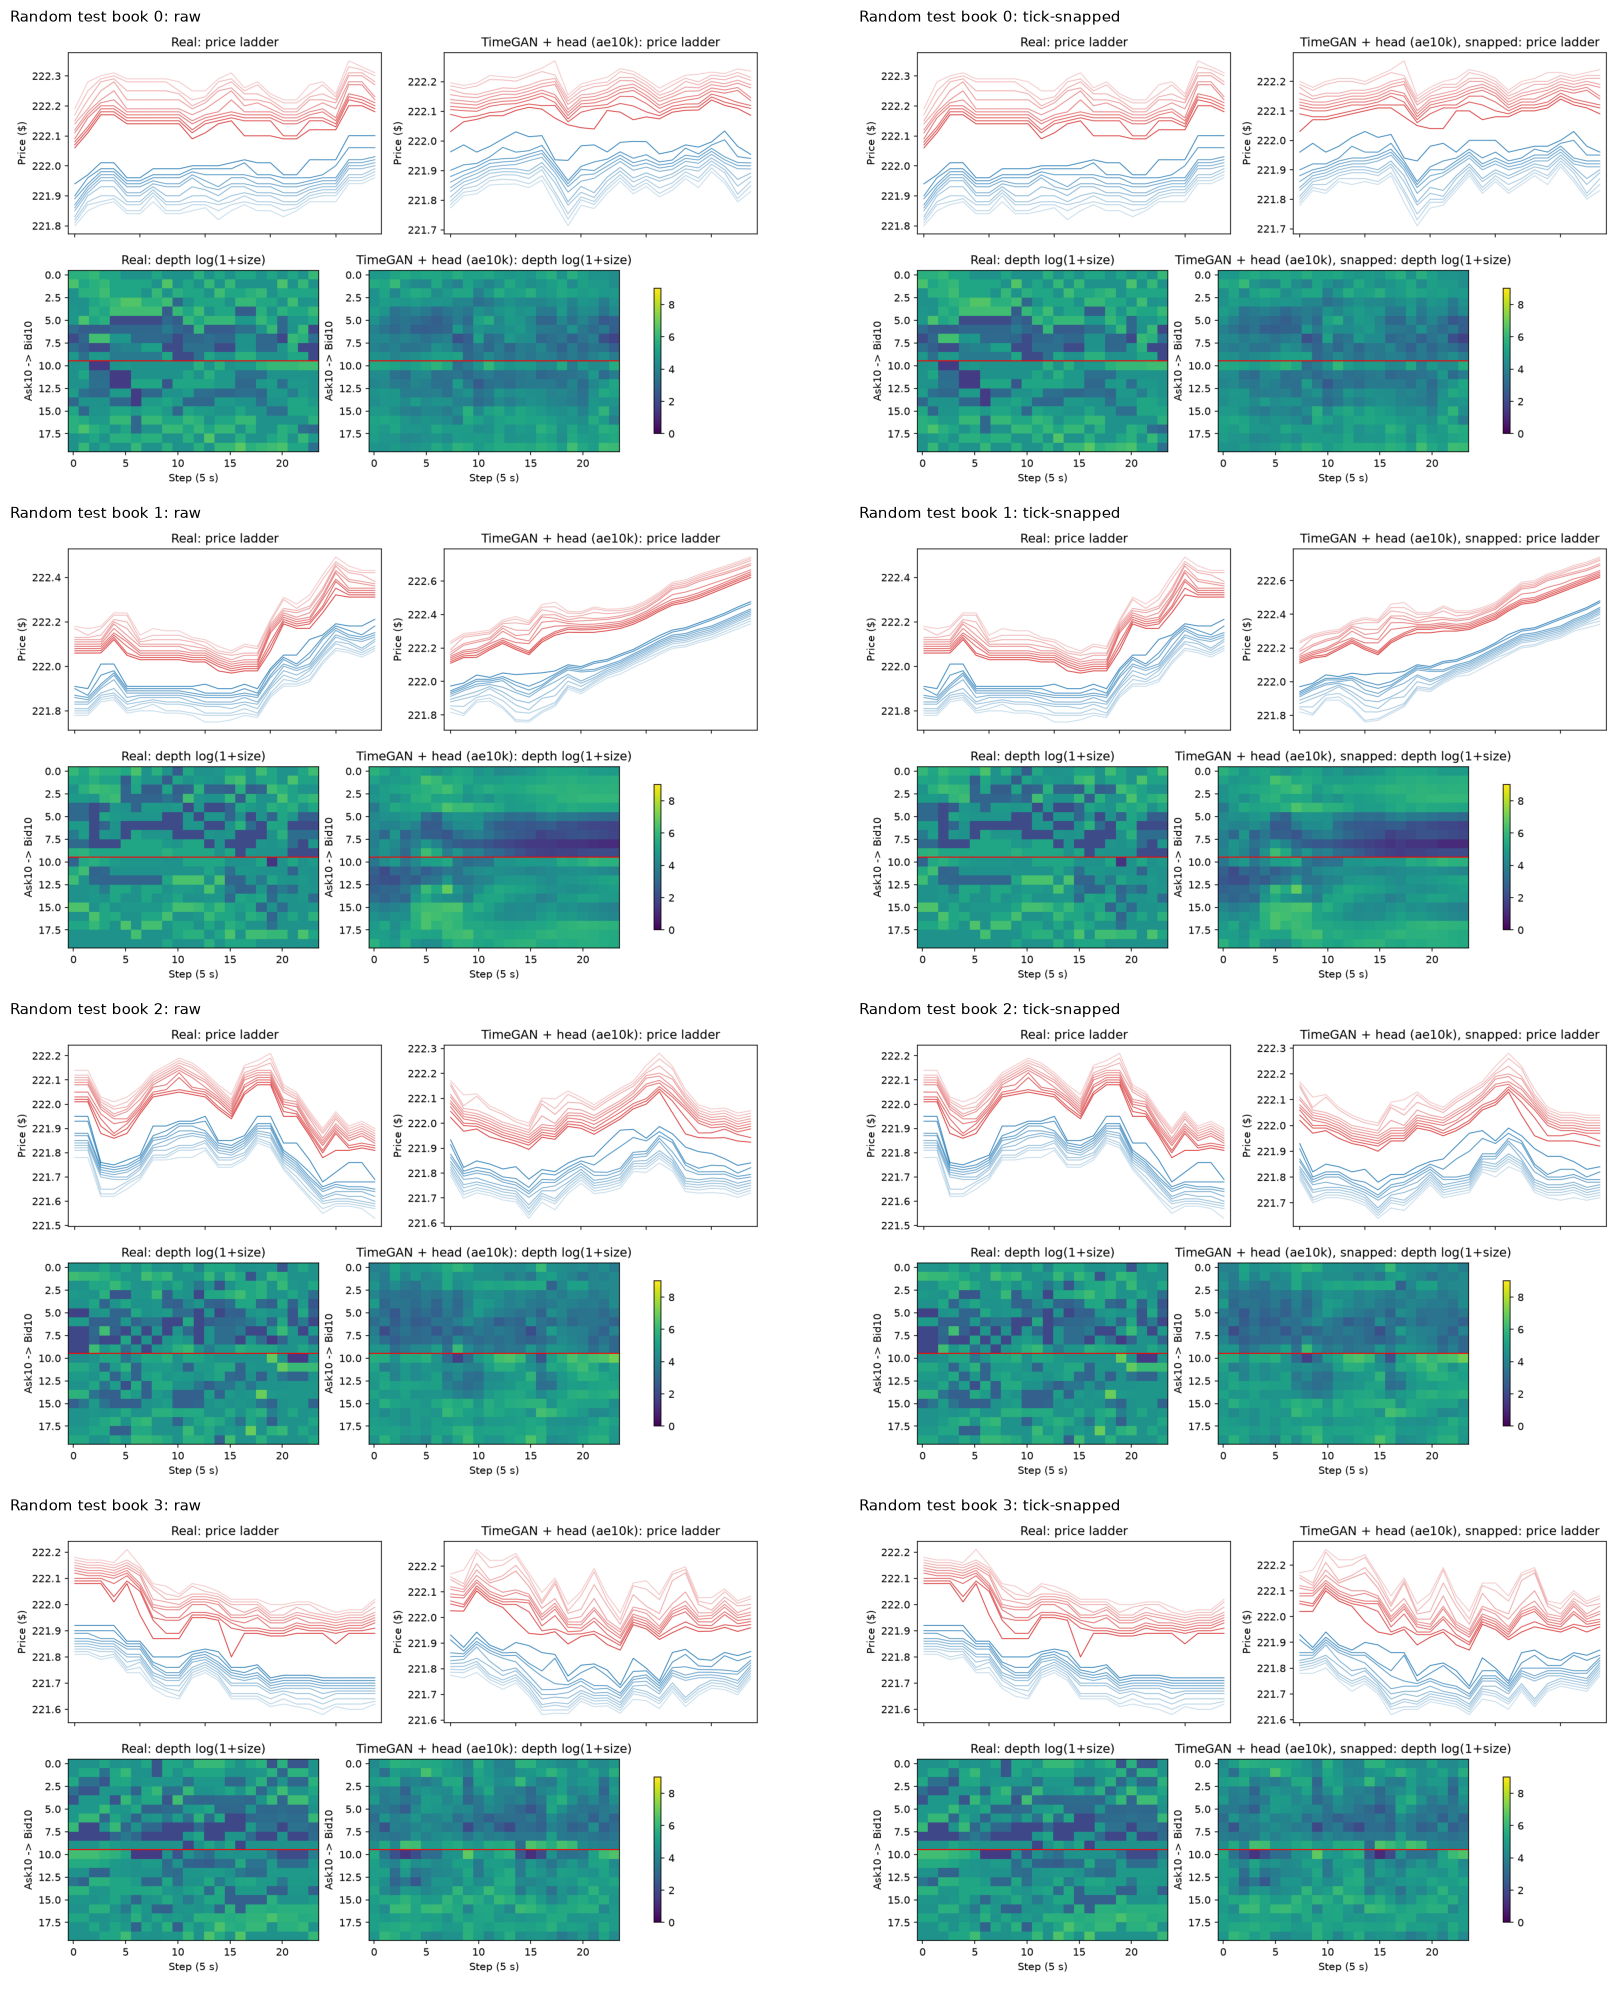

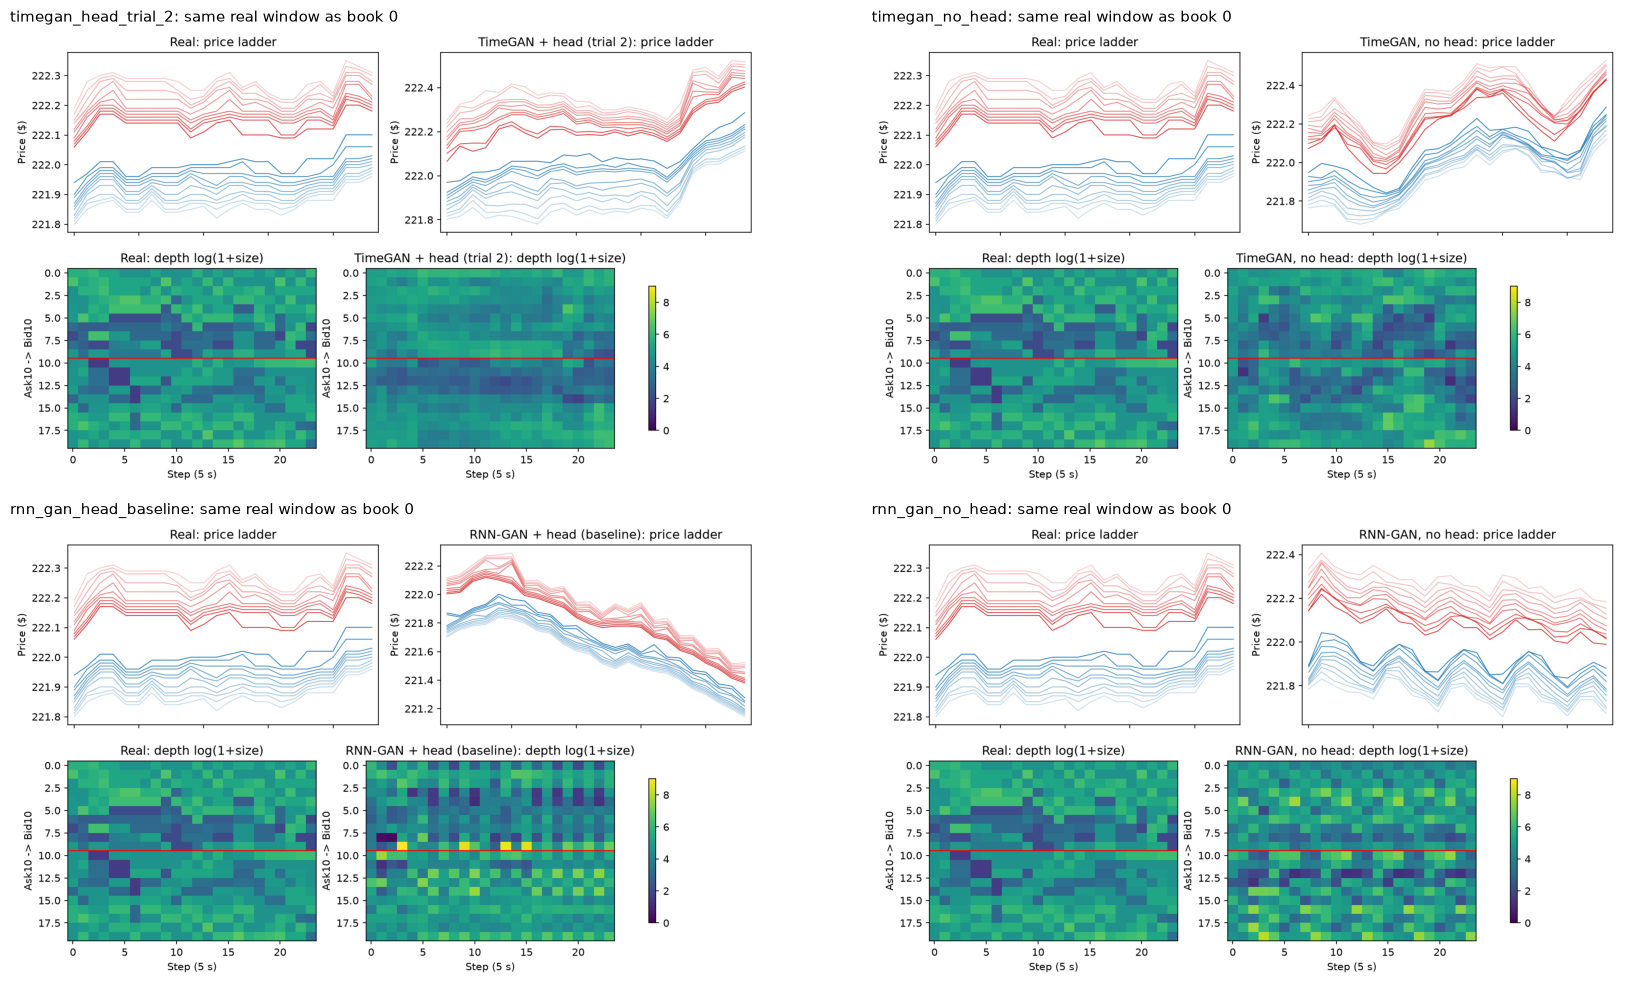

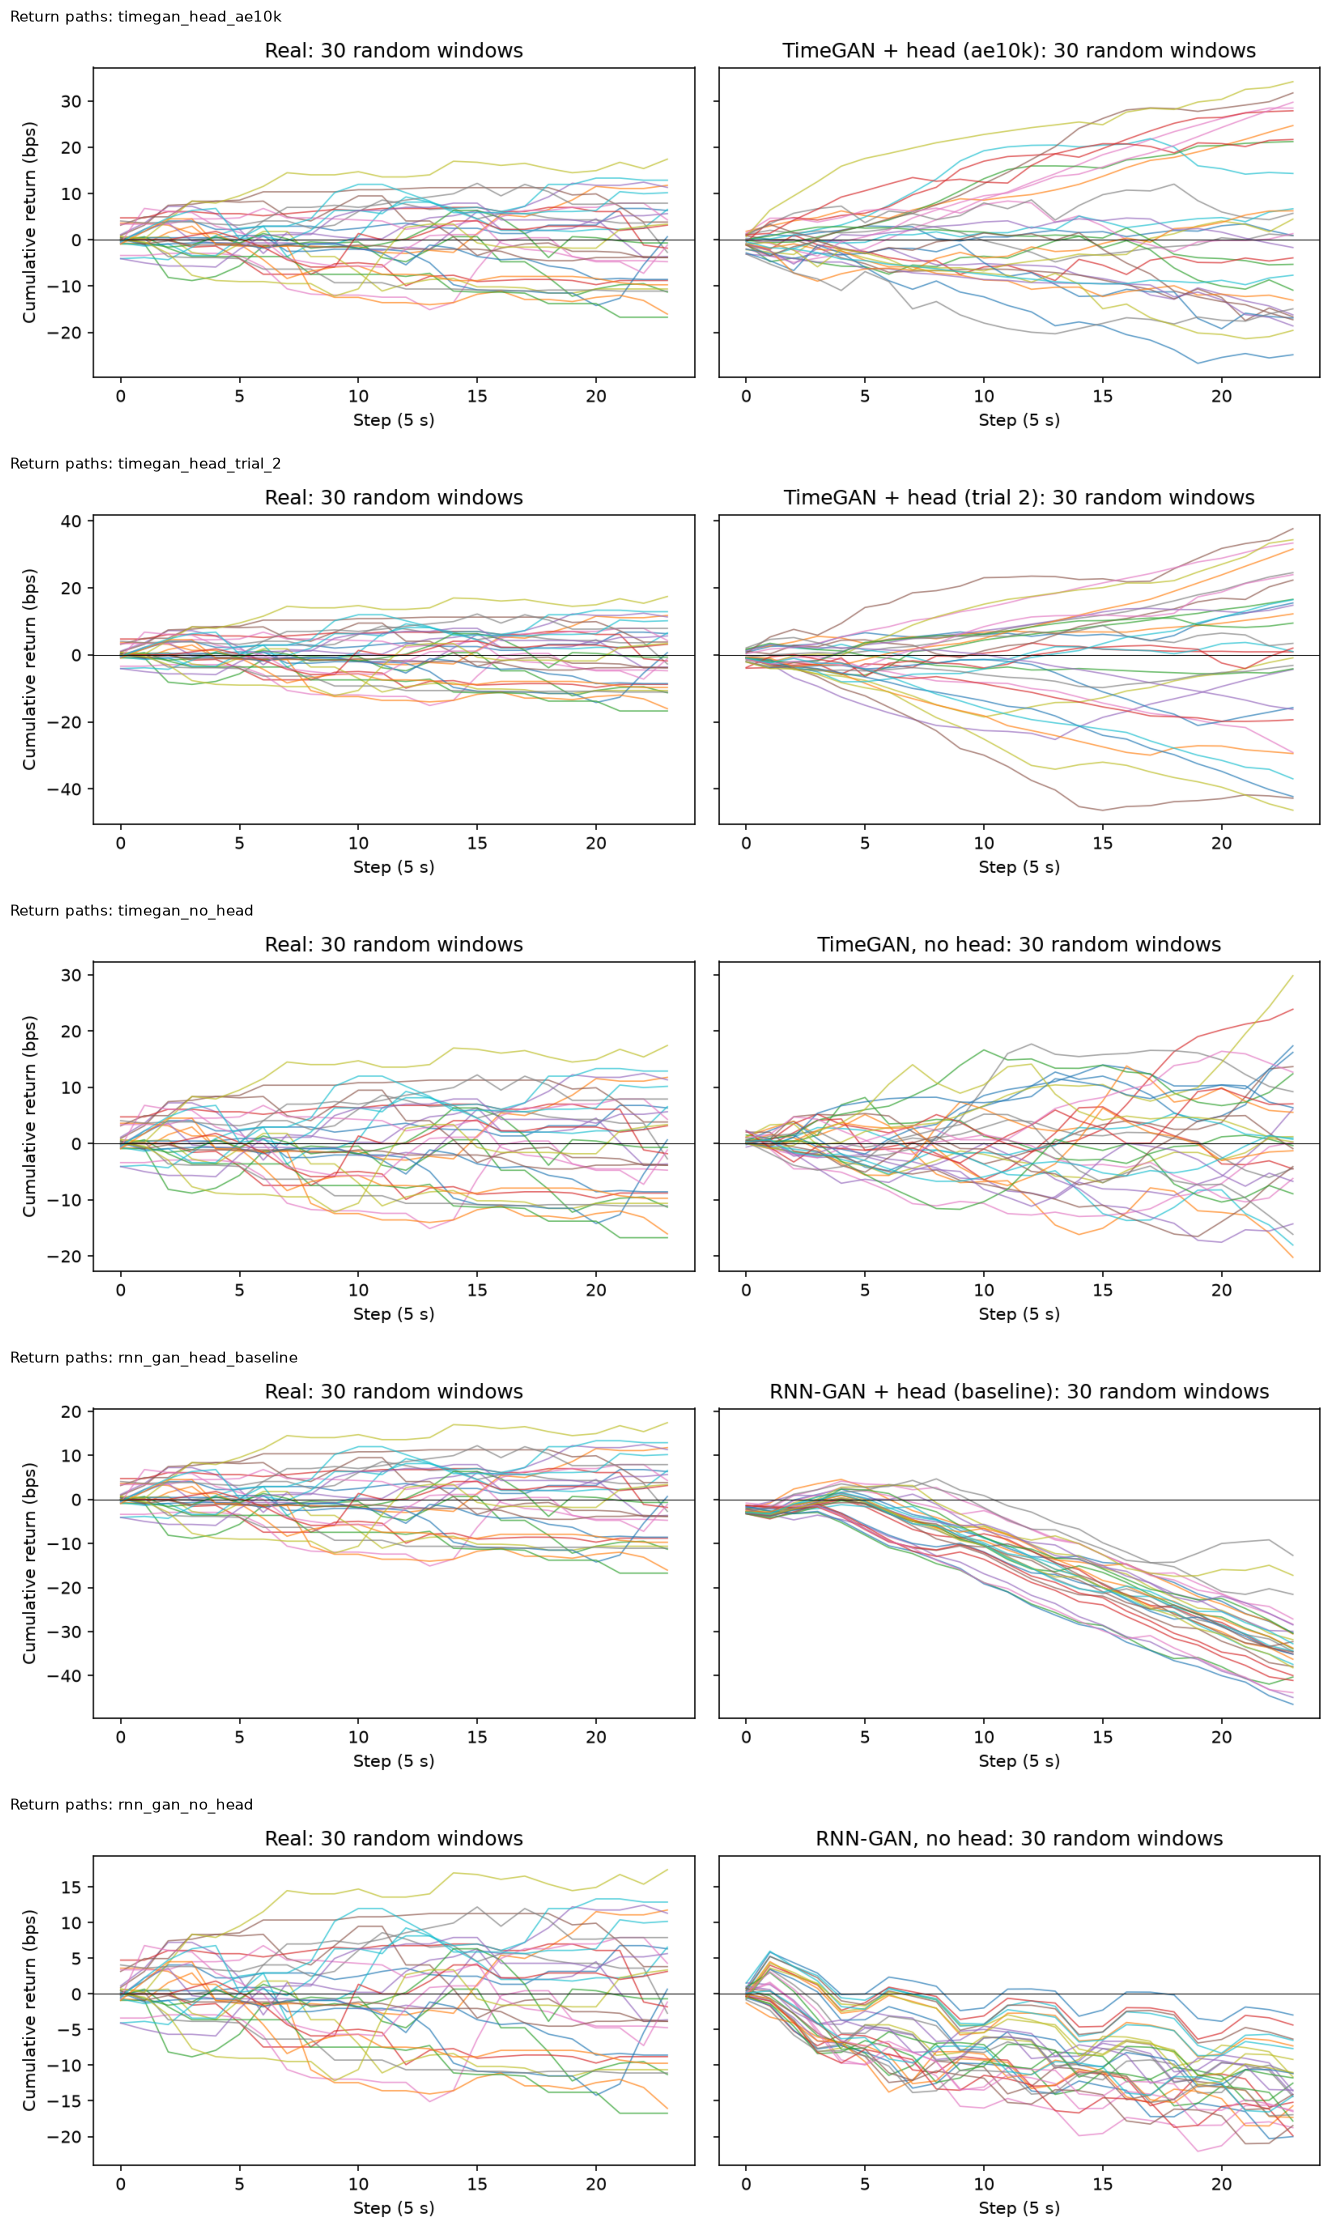

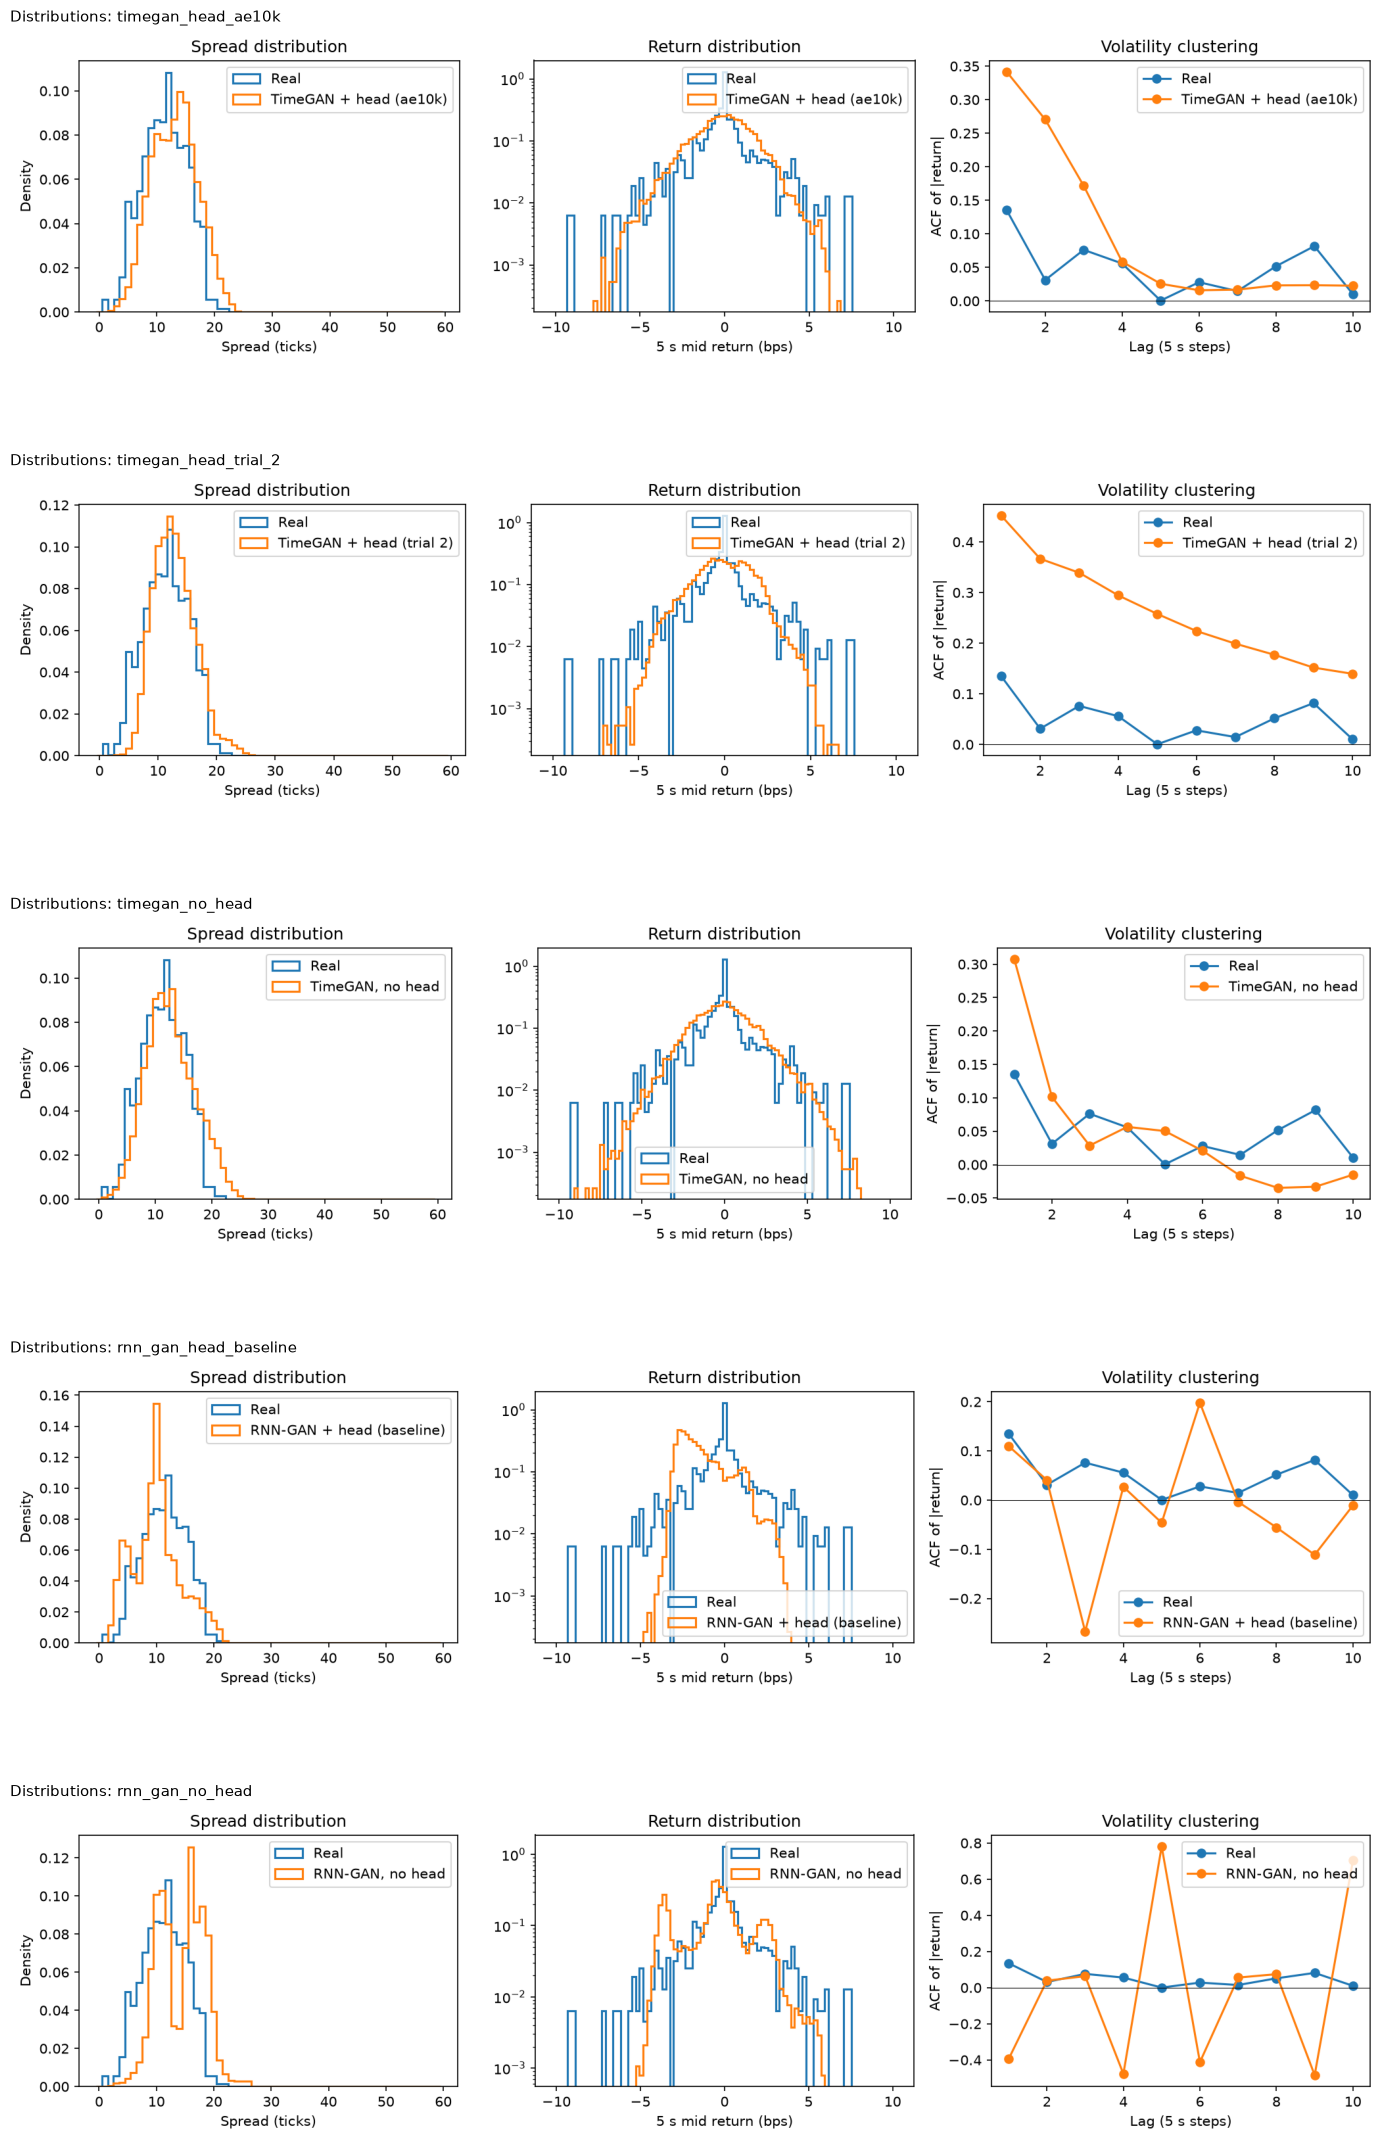

In [8]:
def show(paths, titles, ncols=1, w=14, h=4.5):
    """Show saved PNGs in a grid with titles."""
    nrows = -(-len(paths) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(w, h * nrows), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, p, t in zip(axes.ravel(), paths, titles):
        ax.imshow(mpimg.imread(p)); ax.set_title(t, loc="left", fontsize=11)
    fig.tight_layout(); plt.show()

s = "timegan_head_ae10k"
show([F / f"book_{s}_{k}{x}.png" for k in range(4) for x in ("", "_snapped")],
     [f"Random test book {k}: {v}" for k in range(4) for v in ("raw", "tick-snapped")], ncols=2, w=18, h=5)

others = ["timegan_head_trial_2", "timegan_no_head", "rnn_gan_head_baseline", "rnn_gan_no_head"]
show([F / f"book_{o}_0.png" for o in others], [f"{o}: same real window as book 0" for o in others], ncols=2, w=18, h=5)

models = [s] + others
show([F / f"paths_{m}.png" for m in models], [f"Return paths: {m}" for m in models])
show([F / f"dists_{m}.png" for m in models], [f"Distributions: {m}" for m in models])